# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') 
usage = pd.read_csv('/datasets/usage.csv') 

In [3]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


reg_date and churn_date need to be changed to Dtype date time

In [9]:
usage.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


date has to be changed to Dtype date time

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: 

***users:***
 - **city:** muestra un aproximado de 11% de valores nulos, requiere más exploración.
 - **churn_date:** muestra un aproximado de 88% de valores nulos, se mantiene ya que muestra los clientes activos.

***usage:***
 - **date:** muestra un 1.25% de valores nulos, se puede ignorar ya que no afecta las preguntas de negocio actuales.
 - **duration:** muestra un aproximado de 55% de valores nulos, se puede mantener ya que es un espacio que solo afecta llamadas y no mensajes de texto, es importante ignorar al calcular información de llamadas.
 - **length:** muestra un aproximado de 44% de valores nulos, es el contrario de duration, aplicando solo para mensajes de texto, misma regla aplica.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
def numeric_analisys(df, columns):
    print('description \n', df[columns].describe(),'\n')
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 2.5 * IQR

        print(col)
        print('Lower limit \n', df[df[col] < lower])
        print('Lower limit unique: ', df[df[col] < lower][col].nunique())
        print('Total under lower limit unique: ', (df[col] < lower).sum())
        print('Upper limit \n', df[df[col] > upper])
        print('Upper limit unique: ', df[df[col] > upper][col].nunique())
        print('Total over upper limit: ', (df[col] > upper).sum())
        print()

def numeric_boxplot(df,columns):
    for col in columns:
        sns.boxplot(x=df[col], color='skyblue')
        plt.title(f'boxplot de {col}')
        plt.show()
        

description 
             user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000 

user_id
Lower limit 
 Empty DataFrame
Columns: [user_id, first_name, last_name, age, city, reg_date, plan, churn_date]
Index: []
Lower limit unique:  0
Total under lower limit unique:  0
Upper limit 
 Empty DataFrame
Columns: [user_id, first_name, last_name, age, city, reg_date, plan, churn_date]
Index: []
Upper limit unique:  0
Total over upper limit:  0

age
Lower limit 
       user_id first_name last_name  age      city  \
12      10012    Mariana     Lopez -999  Medellín   
146     10146     Carlos   Ramirez -999       GDL   
171     10171     Carlos     Lopez -999  Medellín   
243     10243        Ana     Gomez -999       MTY   
297     10297     Carlos     Gomez -999  Mede

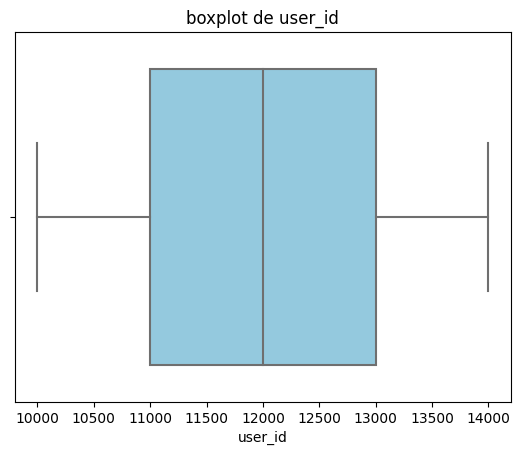

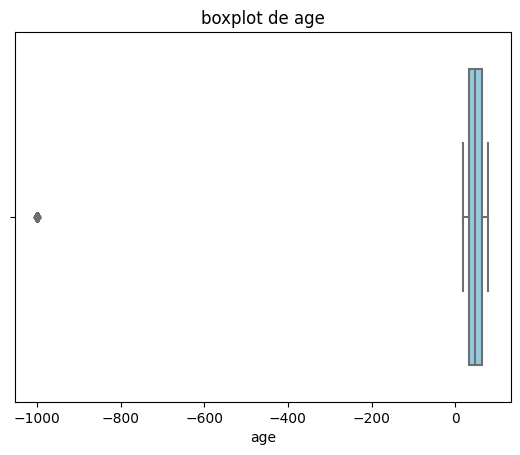

In [13]:
users_numeric = ['user_id', 'age'] # explorar columnas numéricas de users
numeric_analisys(users,users_numeric)

numeric_boxplot(users,users_numeric)

- La columna `user_id` No tiene datos fuera de los limites.
- La columna `age` solo tiene un tipo de dato fuera de limite que es `-999` de estos hay 55 lo cual representa un 1.38% de los datos.

description 
                 id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000 

id
Lower limit 
 Empty DataFrame
Columns: [id, user_id, type, date, duration, length]
Index: []
Lower limit unique:  0
Total under lower limit unique:  0
Upper limit 
 Empty DataFrame
Columns: [id, user_id, type, date, duration, length]
Index: []
Upper limit unique:  0
Total over upper limit:  0

user_id
Lower limit 
 Empty DataFrame
Columns: [id, user_id, type, date, duration, length]
Index: []
Lower limit unique:  0
Total under l

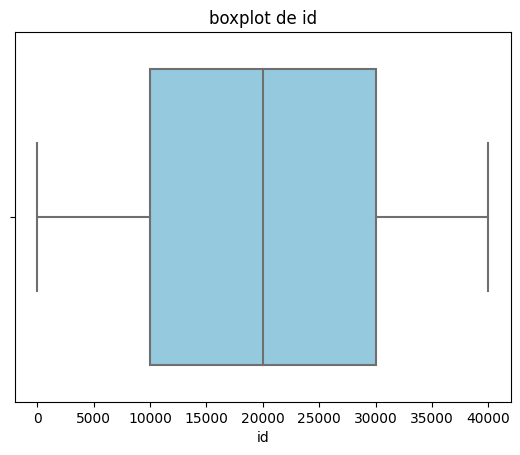

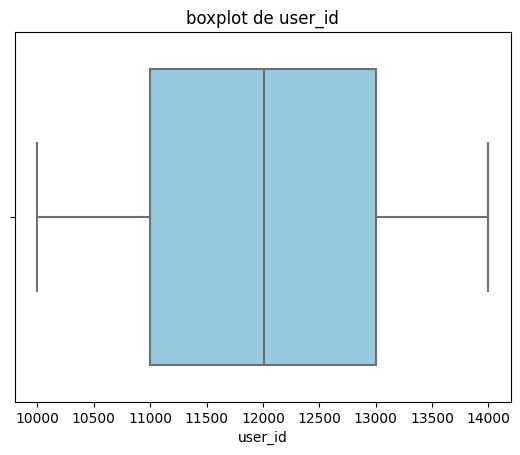

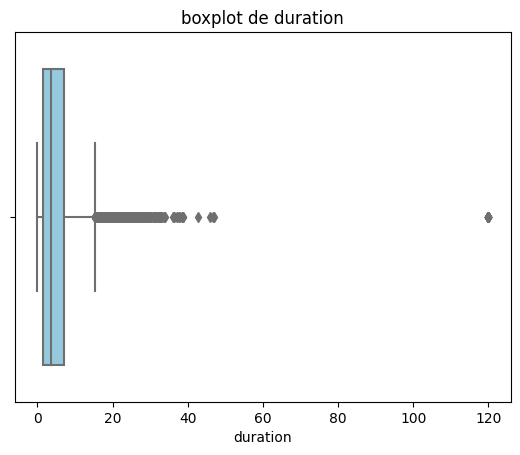

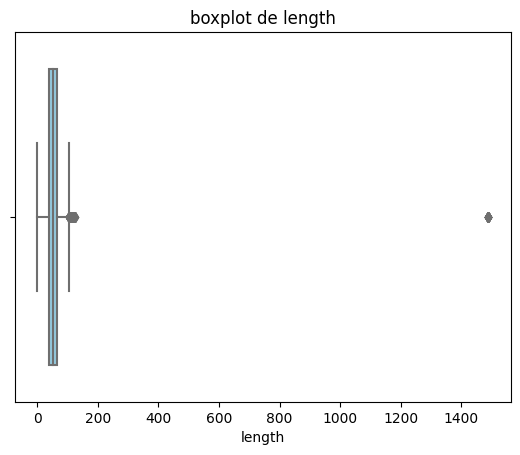

In [14]:
# explorar columnas numéricas de usage
usage_numeric = ['id','user_id', 'duration', 'length']
numeric_analisys(usage, usage_numeric)
numeric_boxplot(usage, usage_numeric)

In [15]:
print("Registros con exactamente 120 minutos:", (usage['duration'] == 120.0).sum())
print("Registros cerca de 120 (119-121):", ((usage['duration'] >= 119) & (usage['duration'] <= 121)).sum())
print("Registros con exactamente 1490 caracteres:", (usage['length'] == 1490.0).sum())

Registros con exactamente 120 minutos: 30
Registros cerca de 120 (119-121): 30
Registros con exactamente 1490 caracteres: 30


- Las columnas `id` y `user_id` No tienen datos fuera de los limites.
- Las columnas `length` y `duration` tienen datos muy por encima del limite superior que probablemente sean errores de imputación, ya que además de estar muy fuera del limite, son numeros muy exactos y se manifiestan repetidamente sin tener otros datos cercanos.
  - `duration` tiene 30 registros de 120 minutos, esto representa un 0.75% de los datos.
  - `length` tiene 30 registros de 1490 caracteres que además se ven en mensajes de texto y llamadas, esto representa un 0.75% de los datos.

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(col)
    print(users[col].describe())
    print(users[col].value_counts())
    print(users[col].value_counts(normalize=True))
    print()

city
count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: city, dtype: float64

plan
count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object
Basico     2595
Premium    1405
Name: plan, dtype: int64
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64



- La columna `city` tiene un 2% de valores invalidos '?'
- La columna `plan` no tiene ningun valor invalido, y el plan basico es el más común.

In [17]:
# explorar columna categórica de usage
print(usage['type'].describe())
print(usage['type'].value_counts())
print(usage['type'].value_counts(normalize=True))

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object
text    22092
call    17908
Name: type, dtype: int64
text    0.5523
call    0.4477
Name: type, dtype: float64


- La columna `type` no tiene ningun valor invalido ambas categorias estan relativamente cerca


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
    -  Las columnas que tienen valores inválidos son `age`, `city`, `duration` y   `length` 
- ¿Qué acción tomarías?
    - para `age` llenar con la mediana.
    - para `city` marcar como NA los `?`
    - para `duration` limpiar los datos que estam muy por fuera de lo esperado `120`
    - para `length` limpiar los datos que estam muy por fuera de lo esperado  `1490`

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
def date_check(df, columns, year_limit):
    for col in columns:
        df[col] = pd.to_datetime(df[col], errors="coerce") 
        print(col)
        print(df[col].dt.year.describe())
        print(f'Negative dates:', df[df[col].dt.year < 0][col].count())
        print(f'Dates over {year_limit}', df[df[col].dt.year > year_limit][col].count())
        print()

In [19]:
# Convertir a fecha la columna `reg_date` de users
users_dates = ['reg_date'] # completa el código
year_limit = 2024
date_check(users, users_dates, year_limit)

reg_date
count    4000.000000
mean     2023.034000
std         0.866044
min      2022.000000
25%      2022.000000
50%      2023.000000
75%      2024.000000
max      2026.000000
Name: reg_date, dtype: float64
Negative dates: 0
Dates over 2024 40



In [20]:
# Convertir a fecha la columna `date` de usage
usage_dates = ['date']  # completa el código
date_check(usage, usage_dates, year_limit)

date
count    39950.0
mean      2024.0
std          0.0
min       2024.0
25%       2024.0
50%       2024.0
75%       2024.0
max       2024.0
Name: date, dtype: float64
Negative dates: 0
Dates over 2024 0



En `date`, unicamente hay datos del año 2024.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? si en `reg_date` tenemos datos de `2026`.
- ¿Qué harías con ellas? Marcarlas como no validas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [23]:
#prelimpieza
print('NA duration antes:', usage['duration'].isna().sum())
print('NA length antes:', usage['length'].isna().sum())

#limpiar datos de duration y length
usage['duration'] = usage['duration'].replace(120.0, pd.NA)
usage['length'] = usage['length'].replace(1490.0, pd.NA)

#verificar cambios
print('NA duration despues:', usage['duration'].isna().sum())
print('NA length despues:', usage['length'].isna().sum())

NA duration antes: 22076
NA length antes: 17896
NA duration despues: 22106
NA length despues: 17926


In [24]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].dt.year.replace(2026, pd.NA)

# Verificar cambios
print(users['reg_date'].isna().sum())

40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()


type
call    0.000782
text    1.000000
Name: duration, dtype: float64

In [26]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()


type
call    1.000000
text    0.000815
Name: length, dtype: float64

Los nulos en `duration` y `length` son dependientes de la categoria type

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text':'sum', 'is_call':'sum', 'duration':'sum'}).reset_index()
    
# observar resultado
print(usage_agg.head(3))


   user_id  is_text  is_call  duration
0    10000        7        3     23.70
1    10001        5       10     33.18
2    10002        5        2     10.74


In [28]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes', 'is_call':'cant_llamadas', 'duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(
    usage_agg,
    users,
    how='left',
    on='user_id'
)
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas}
num_col = ['cant_mensajes',	'cant_llamadas', 'cant_minutos_llamada']


for col in num_col:
    print(col)
    print(f'{"median":<12}{user_profile[col].median()}')
    print(user_profile[col].describe())
    print()



cant_mensajes
median      5.0
count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64

cant_llamadas
median      4.0
count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64

cant_minutos_llamada
median      19.68
count    3999.000000
mean       22.416829
std        15.051059
min         0.000000
25%        11.085000
50%        19.680000
75%        30.995000
max       105.540000
Name: cant_minutos_llamada, dtype: float64



In [31]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

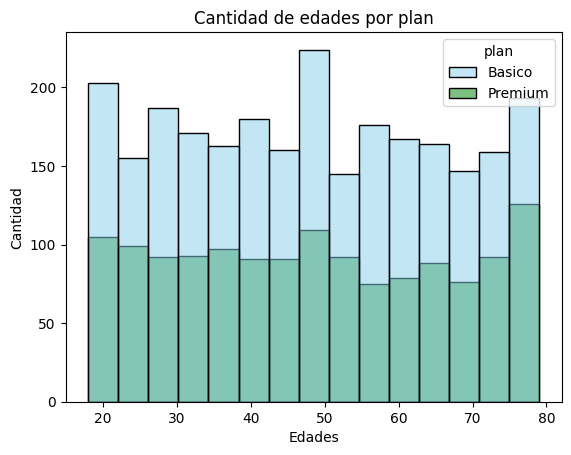

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(data= user_profile, x= 'age', bins=15,hue='plan', palette=['skyblue','green'])
plt.xlabel('Edades')
plt.ylabel('Cantidad')
plt.title('Cantidad de edades por plan')
plt.show()

💡Insights: 
- Distribución simetrica.
- Ambos planes muestran una mayoria de usuarios cercanos a los 50.
- la distribuición no varia mucho entre planes.

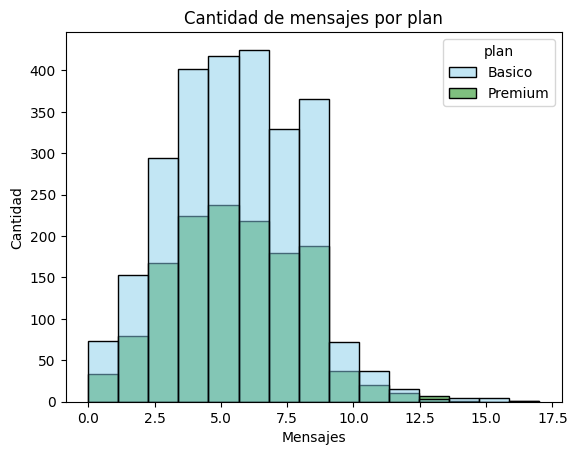

In [33]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data= user_profile, x= 'cant_mensajes',bins=15 , hue='plan', palette=['skyblue','green'])
plt.xlabel('Mensajes')
plt.ylabel('Cantidad')
plt.title('Cantidad de mensajes por plan')
plt.show()

💡Insights: 
- Distrubición sesgada un poco a la derecha.
- La mayoria de los usuarios mandan un poco más de 5 mensajes.
- la distribuición no varia mucho entre planes.

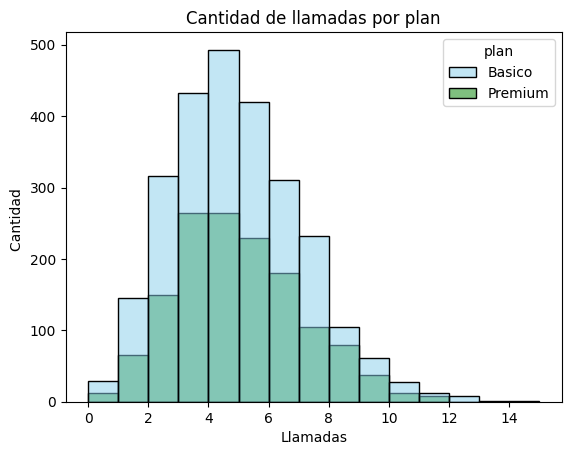

In [34]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data= user_profile, x= 'cant_llamadas', bins=15, hue='plan', palette=['skyblue','green'])
plt.xlabel('Llamadas')
plt.ylabel('Cantidad ')
plt.title('Cantidad de llamadas por plan')
plt.show()

💡Insights: 
- Distribución sesgada a la derecha.
- La distribuición no varia mucho entre planes.

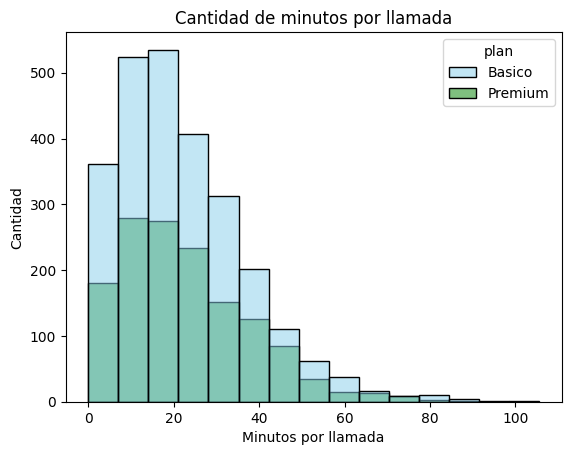

In [35]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data= user_profile, x= 'cant_minutos_llamada', bins=15 , hue='plan', palette=['skyblue','green'])
plt.xlabel('Minutos por llamada')
plt.ylabel('Cantidad')
plt.title('Cantidad de minutos por llamada')
plt.show()


💡Insights: 
- Distribución sesgada a la derecha
- La distribuición no varia mucho entre planes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

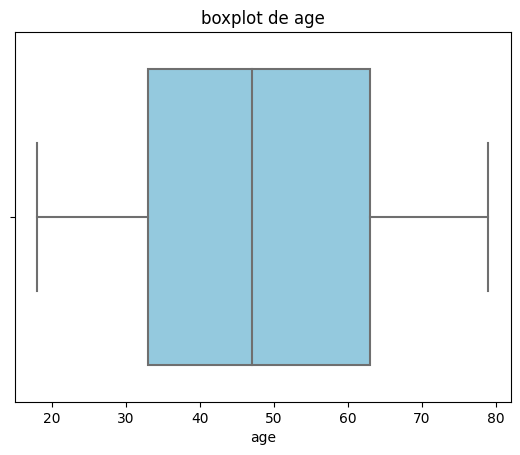

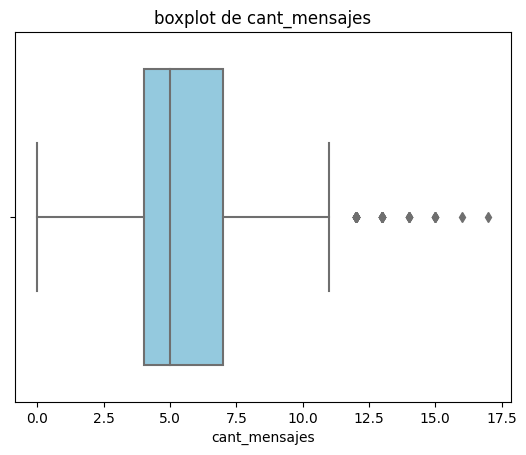

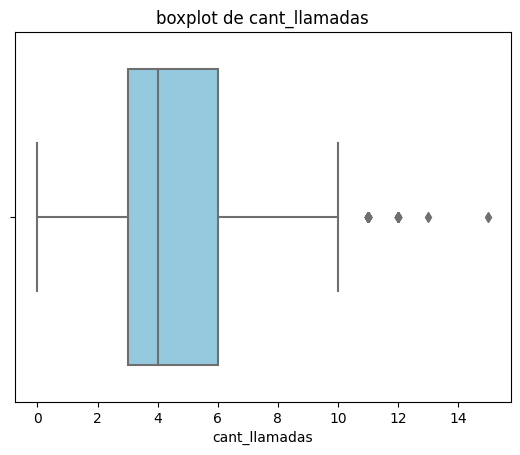

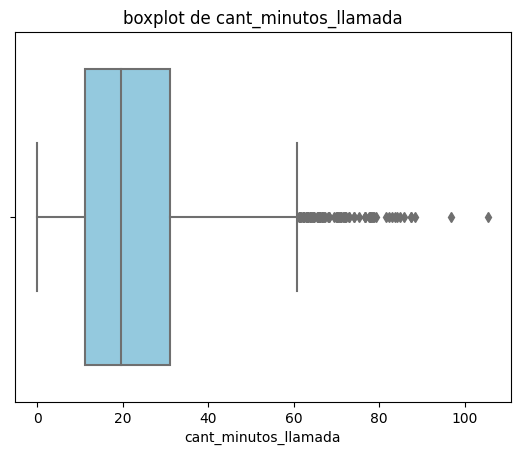

In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
numeric_boxplot(user_profile,columnas_numericas)

💡Insights: 
- Age: No tiene outliers
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

numeric_analisys(user_profile,columnas_limites)
    

description 
        cant_mensajes  cant_llamadas  cant_minutos_llamada
count    3999.000000    3999.000000           3999.000000
mean        5.524381       4.478120             22.416829
std         2.358416       2.144238             15.051059
min         0.000000       0.000000              0.000000
25%         4.000000       3.000000             11.085000
50%         5.000000       4.000000             19.680000
75%         7.000000       6.000000             30.995000
max        17.000000      15.000000            105.540000 

cant_mensajes
Lower limit 
 Empty DataFrame
Columns: [user_id, cant_mensajes, cant_llamadas, cant_minutos_llamada, first_name, last_name, age, city, reg_date, plan, churn_date]
Index: []
Lower limit unique:  0
Total under lower limit unique:  0
Upper limit 
       user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada first_name  \
1158    11159             15              2                  5.15    Mariana   
1196    11197             17              3

In [38]:
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,22.416829
std,2.358416,2.144238,15.051059
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.085000
50%,5.000000,4.000000,19.680000
75%,7.000000,6.000000,30.995000
max,17.000000,15.000000,105.540000


💡Insights: 
- cant_mensajes: mantener outliers, por que son menos del 1% y pueden ser datos reales.
- cant_llamadas: mantener outlier, por que son menos del 1% y pueden ser datos reales.
- cant_minutos_llamada: mantener outliers, por que son menos del 1% y pueden ser datos reales.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where((user_profile['cant_mensajes'] < 5) & (user_profile['cant_llamadas'] < 5), 'Bajo uso',\
                                        np.where((user_profile['cant_mensajes'] < 10) & (user_profile['cant_llamadas'] < 10), 'Uso medio',\
                                                'Alto uso'))

In [40]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(user_profile['age'] < 30, 'Joven',\
                                        np.where(user_profile['age']< 60, 'Adulto',\
                                            'Adulto Mayor'))

In [42]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

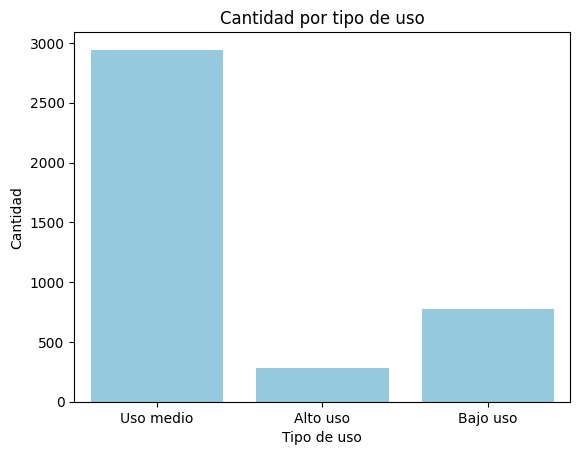

In [43]:
# Visualización de los segmentos por uso

sns.countplot(data= user_profile,x= 'grupo_uso', palette=['skyblue'])

plt.xlabel('Tipo de uso')
plt.ylabel('Cantidad')
plt.title('Cantidad por tipo de uso')

plt.show()


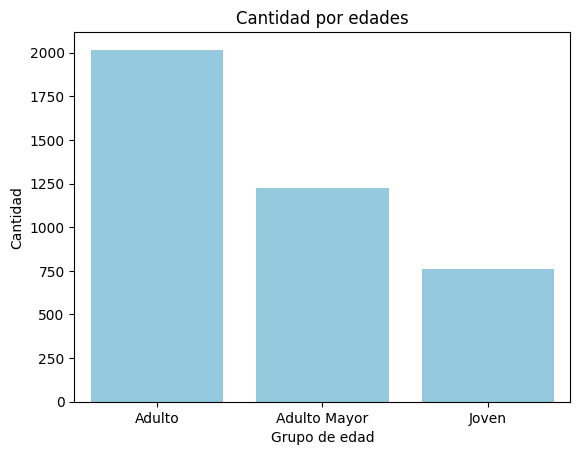

In [44]:
# Visualización de los segmentos por edad

sns.countplot(data= user_profile,x= 'grupo_edad', palette=['skyblue'])

plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad')
plt.title('Cantidad por edades')

plt.show()


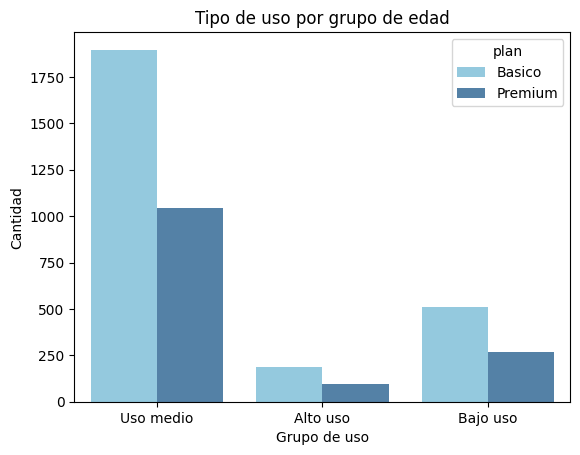

In [45]:
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    hue='plan',
    palette=['skyblue', 'steelblue']
)

plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad')
plt.title('Tipo de uso por grupo de edad')

plt.show()

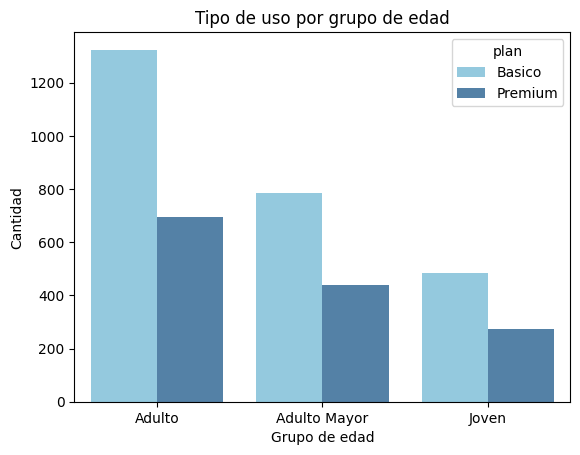

In [46]:
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    hue='plan',
    palette=['skyblue', 'steelblue']
)

plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad')
plt.title('Tipo de uso por grupo de edad')

plt.show()

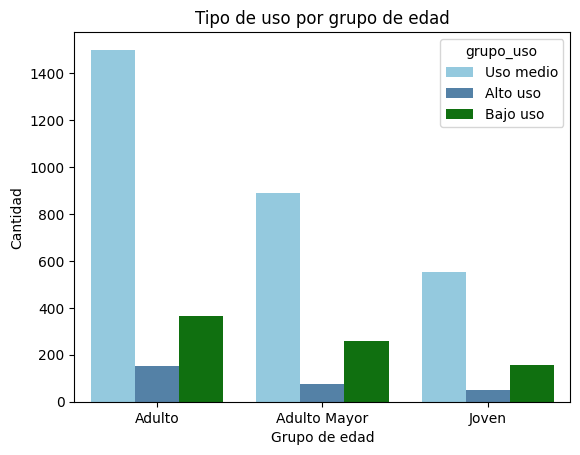

In [47]:
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    hue='grupo_uso',
    palette=['skyblue', 'steelblue', 'green']
)

plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad')
plt.title('Tipo de uso por grupo de edad')

plt.show()

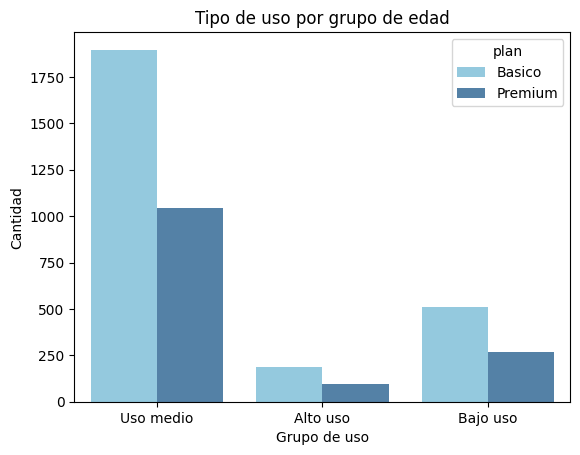

In [48]:
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    hue='plan',
    palette=['skyblue', 'steelblue']
)

plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad')
plt.title('Tipo de uso por grupo de edad')

plt.show()

In [49]:
tabla_grupo_uso = pd.crosstab(user_profile['grupo_edad'], user_profile['grupo_uso'], normalize='index')
tabla_grupo_uso

grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,0.075855,0.180466,0.743679
Adulto Mayor,0.060556,0.210311,0.729133
Joven,0.067105,0.206579,0.726316


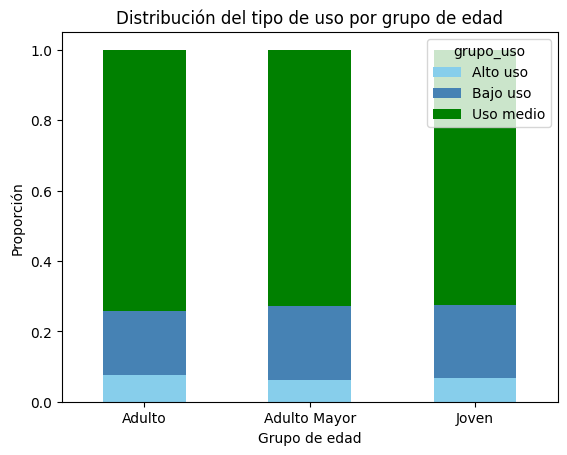

In [50]:
tabla_grupo_uso.plot(kind='bar', stacked=True, color=['skyblue', 'steelblue', 'green'])
plt.xlabel('Grupo de edad')
plt.xticks(rotation=0)
plt.ylabel('Proporción')
plt.title('Distribución del tipo de uso por grupo de edad')

plt.show()

In [51]:
tabla_grupo_uso_plan = pd.crosstab(user_profile['grupo_uso'], user_profile['plan'], normalize='index')
tabla_grupo_uso_plan

plan,Basico,Premium
grupo_uso,,
Alto uso,0.665468,0.334532
Bajo uso,0.658098,0.341902
Uso medio,0.644580,0.355420


In [52]:
tabla_grupo_uso_plan.plot(kind='bar', stacked=True, color=['skyblue', 'steelblue')
plt.xlabel('Grupo de edad')
plt.xticks(rotation=0)
plt.ylabel('Proporción')
plt.title('Distribución del tipo de uso por grupo de edad')

plt.show()

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' (1009682714.py, line 1)

In [ ]:
tabla_plan = pd.crosstab(user_profile['grupo_edad'], user_profile['plan'], normalize='index')
tabla_plan

In [ ]:
tabla_plan.plot(kind='bar', stacked=True, color=['skyblue', 'steelblue', 'green'])
plt.xlabel('Grupo de edad')
plt.xticks(rotation=0)
plt.ylabel('Proporción')
plt.title('Distribución del tipo de uso por grupo de edad')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

_**users:**_

- ***city:*** muestra un aproximado de 11% de valores nulos, se puede ignorar ya que no afecta las preguntas de negocio actuales.
- ***churn_date:*** muestra un aproximado de 88% de valores nulos, se mantiene ya que muestra los clientes activos.
- ***age*** solo tiene un tipo de dato fuera de limite que es `-999` de estos hay 55 lo cual representa un 1.38% de los datos, estos datos fueron imputados con la mediana.

_**usage:**_

- **date:** muestra un 1.25% de valores nulos, se puede ignorar ya que no afecta las preguntas de negocio actuales.
- **duration:** muestra un aproximado de 55% de valores nulos, se puede mantener ya que es un espacio que solo afecta llamadas y no mensajes de texto, es importante ignorar al calcular información de llamadas.
- **length:** muestra un aproximado de 44% de valores nulos, es el contrario de duration, aplicando solo para mensajes de texto, misma regla aplica.
- Las columnas ***length*** y ***duration*** tienen datos muy por encima del limite superior que probablemente sean errores de imputación, ya que además de estar muy fuera del limite, son números muy exactos y se manifiestan repetidamente sin tener otros datos cercanos.
  - ***duration*** tiene 30 registros de 120 minutos, esto representa un 0.75% de los datos.
  - ***length*** tiene 30 registros de 1490 caracteres que además se ven en mensajes de texto y llamadas, esto representa un 0.75% de los datos estos datos fueron eliminados.


🔍 **Segmentos por Edad**

- El grupo de adultos es el que muestra más cantidad de usuarios en general.
- Los porcentajes de uso y acceso a planes premium es el mismo para todos los grupos de edades.
- Los jóvenes son los que menos hacen uso de el servicio. 


📊 **Segmentos por Nivel de Uso**

- La mayoría de los usuarios tienen un uso medio del servicio.
- La proporción de uso entre usuarios premium y básico es la misma.




💡 **Recomendaciones**
- Potenciar a los usuarios que tienen uso medio para venderles planes premium, esto se puede hacer con ofertas personalizadas basadas en su consumo.
- Mejorar el plan premium, se ve que el no hay diferencia de uso entre planes, por lo que se recomienda añadir beneficios que incentiven el cambio de plan y así aumentar ingresos.
- Aunque no se observan diferencias significativas entre segmentos en el uso actual, existe una oportunidad clara en la activación de usuarios jóvenes y en la optimización del valor percibido de los planes premium, lo que podría impactar directamente en la retención y monetización.
